# ORCD Ablation Visualization

Notebook nay:
- Doc `ORCD/Wo_gpt/ablation_results.csv`, lay dong co `Acc` cao nhat cho moi `case_id`.
- Doc baseline ORCD tu `ORCD/GPT_4o_mini/weight/S-teacher-bert.csv` va lay best epoch theo `Accuracy`.
- Ve line chart (co markers) cho 3 metric: `Acc`, `MacF1`, `ClickF1` bang seaborn.

Mapping case:
- Case 1: w/o TF
- Case 2: w/o TA
- Case 3: w/o {VA,VD}
- Case 4: w/o {VA,VD}&TF
- Case 5: w/o {VA,VD}&TA

Summary (ORCD best epoch + case-wise mean over n samples):


,Model,Epoch,n_samples,Acc,MacF1,ClickF1
0,ORCD,7.0,NaN,0.946121,0.939926,0.959217
1,w/o TF,NaN,21.0,0.922832,0.914344,0.940922
2,w/o TA,NaN,36.0,0.924417,0.916767,0.941117
3,"w/o {VA,VD}",NaN,34.0,0.934677,0.926932,0.950392
4,"w/o {VA,VD}&TF",NaN,50.0,0.876652,0.850572,0.901493
5,"w/o {VA,VD}&TA",NaN,13.0,0.933036,0.925494,0.948923


/tmp/ipykernel_36202/3455906165.py:164: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(model_name, y, marker=marker, s=120, color=palette[metric], edgecolor='black', linewidth=0.5, zorder=5)


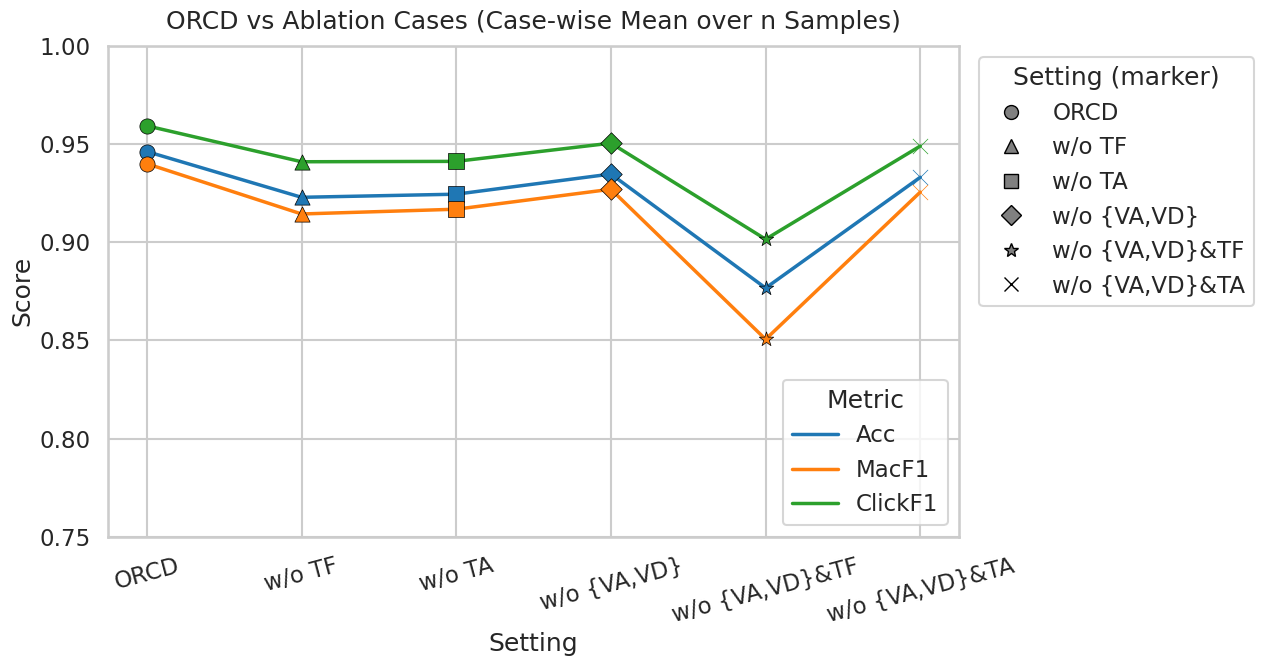

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D

sns.set_theme(style='whitegrid', context='talk')


def find_project_root(start: Path) -> Path:
    """Find NLP workspace root by walking up and checking for ORCD folder."""
    current = start.resolve()
    for candidate in [current] + list(current.parents):
        if (candidate / 'ORCD').exists():
            return candidate
    raise FileNotFoundError('Khong tim thay thu muc goc chua ORCD')


def read_avg_ablation_cases(ablation_csv: Path) -> pd.DataFrame:
    """Read ablation CSV and return mean metrics for each case_id."""
    df = pd.read_csv(ablation_csv)

    required_cols = {'case_id', 'Acc', 'MacF1', 'ClickF1'}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f'Thieu cot trong {ablation_csv}: {sorted(missing)}')

    metric_cols = ['Acc', 'MacF1', 'ClickF1']
    df = df.copy()
    df['case_id'] = pd.to_numeric(df['case_id'], errors='coerce')
    for col in metric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df = df.dropna(subset=['case_id'])
    df = df.dropna(subset=metric_cols, how='all')
    if df.empty:
        return pd.DataFrame(columns=['case_id', 'n_samples', 'Acc', 'MacF1', 'ClickF1'])

    df['case_id'] = df['case_id'].astype(int)

    out = (
        df.groupby('case_id', sort=True, as_index=False)
        .agg(
            n_samples=('case_id', 'size'),
            Acc=('Acc', 'mean'),
            MacF1=('MacF1', 'mean'),
            ClickF1=('ClickF1', 'mean'),
        )
    )
    return out.sort_values('case_id').reset_index(drop=True)


def read_best_orcd_baseline(orcd_csv: Path) -> dict:
    """Read ORCD main result CSV and pick best epoch by Accuracy."""
    df = pd.read_csv(orcd_csv)

    required = {'Accuracy', 'macro_f1', 'true_f1'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f'Thieu cot trong {orcd_csv}: {sorted(missing)}')

    acc_col = pd.to_numeric(df['Accuracy'], errors='coerce')
    if acc_col.isna().all():
        raise ValueError('Cot Accuracy khong co gia tri hop le')

    best_idx = acc_col.idxmax()
    best = df.loc[best_idx]

    epoch_val = int(best['Epoch']) if 'Epoch' in df.columns and pd.notna(best['Epoch']) else int(best_idx)

    return {
        'Model': 'ORCD',
        'Epoch': epoch_val,
        'n_samples': None,
        'Acc': float(best['Accuracy']),
        'MacF1': float(best['macro_f1']),
        'ClickF1': float(best['true_f1']),
    }


root = find_project_root(Path.cwd())
ablation_path = root / 'ORCD' / 'Wo_gpt' / 'ablation_results.csv'
orcd_path = root / 'ORCD' / 'GPT_4o_mini' / 'weight' / 'S-teacher-bert.csv'

avg_case_df = read_avg_ablation_cases(ablation_path)
orcd_baseline = read_best_orcd_baseline(orcd_path)

case_to_label = {
    1: 'w/o TF',
    2: 'w/o TA',
    3: 'w/o {VA,VD}',
    4: 'w/o {VA,VD}&TF',
    5: 'w/o {VA,VD}&TA',
}

labels = ['ORCD', 'w/o TF', 'w/o TA', 'w/o {VA,VD}', 'w/o {VA,VD}&TF', 'w/o {VA,VD}&TA']
markers = ['o', '^', 's', 'D', '*', 'x']

rows = [orcd_baseline]
for case_id in [1, 2, 3, 4, 5]:
    match = avg_case_df[avg_case_df['case_id'] == case_id]
    if match.empty:
        rows.append(
            {
                'Model': case_to_label[case_id],
                'Epoch': None,
                'n_samples': 0,
                'Acc': float('nan'),
                'MacF1': float('nan'),
                'ClickF1': float('nan'),
            }
        )
    else:
        r = match.iloc[0]
        rows.append(
            {
                'Model': case_to_label[case_id],
                'Epoch': None,
                'n_samples': int(r['n_samples']),
                'Acc': float(r['Acc']),
                'MacF1': float(r['MacF1']),
                'ClickF1': float(r['ClickF1']),
            }
        )

plot_df = pd.DataFrame(rows)
plot_df['Model'] = pd.Categorical(plot_df['Model'], categories=labels, ordered=True)
plot_df = plot_df.sort_values('Model').reset_index(drop=True)

print('Summary (ORCD best epoch + case-wise mean over n samples):')
display(plot_df)

plot_long = plot_df.melt(
    id_vars=['Model', 'Epoch', 'n_samples'],
    value_vars=['Acc', 'MacF1', 'ClickF1'],
    var_name='Metric',
    value_name='Score',
)

palette = {'Acc': '#1f77b4', 'MacF1': '#ff7f0e', 'ClickF1': '#2ca02c'}

plt.figure(figsize=(13, 7))
ax = sns.lineplot(
    data=plot_long,
    x='Model',
    y='Score',
    hue='Metric',
    palette=palette,
    linewidth=2.5,
)

# Add case-specific markers on each metric line using the requested marker list.
for model_idx, model_name in enumerate(labels):
    marker = markers[model_idx]
    row = plot_df[plot_df['Model'] == model_name]
    if row.empty:
        continue
    row = row.iloc[0]
    for metric in ['Acc', 'MacF1', 'ClickF1']:
        y = row[metric]
        if pd.isna(y):
            continue
        ax.scatter(model_name, y, marker=marker, s=120, color=palette[metric], edgecolor='black', linewidth=0.5, zorder=5)

metric_handles, metric_labels = ax.get_legend_handles_labels()
if ax.legend_ is not None:
    ax.legend_.remove()

metric_legend = ax.legend(metric_handles, metric_labels, title='Metric', loc='lower right')
ax.add_artist(metric_legend)

marker_handles = [
    Line2D([0], [0], marker=markers[i], color='gray', linestyle='None', markersize=10, markeredgecolor='black', label=labels[i])
    for i in range(len(labels))
]
ax.legend(handles=marker_handles, title='Setting (marker)', loc='upper left', bbox_to_anchor=(1.01, 1))

ax.set_title('ORCD vs Ablation Cases (Case-wise Mean over n Samples)', pad=12)
ax.set_xlabel('Setting')
ax.set_ylabel('Score')
ax.set_ylim(0.75, 1.0)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()